Shape: (5630, 20)

Dtypes:
 CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

Missing values:
 Series([], dtype: int64)

Total duplicate rows: 0

Numeric summary:
                               count        mean        std   min    25%  \
Tenure          

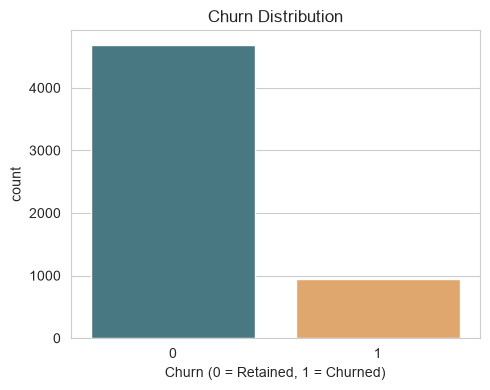

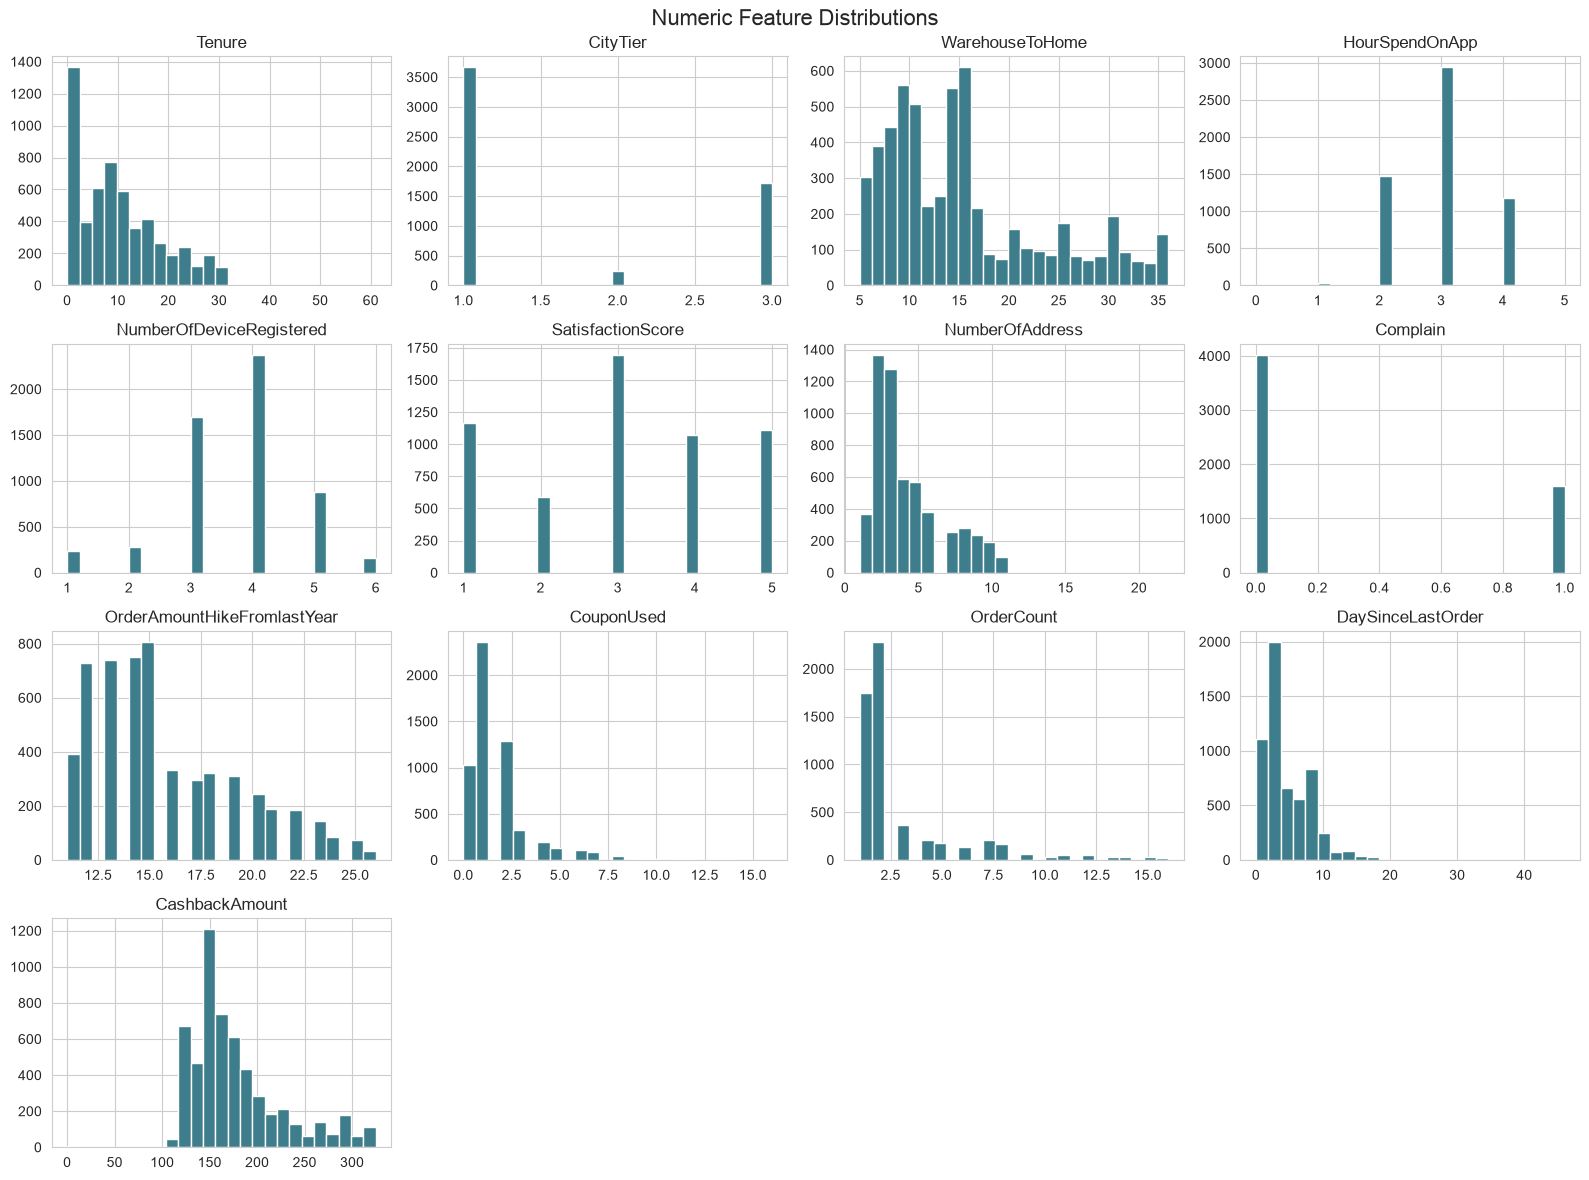


Correlation with Churn:
 Churn                          1.000000
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.074061
NumberOfAddress                0.043931
HourSpendOnApp                 0.018816
CouponUsed                    -0.001430
OrderAmountHikeFromlastYear   -0.007075
OrderCount                    -0.024038
CashbackAmount                -0.154161
DaySinceLastOrder             -0.155871
Tenure                        -0.337831
Name: Churn, dtype: float64


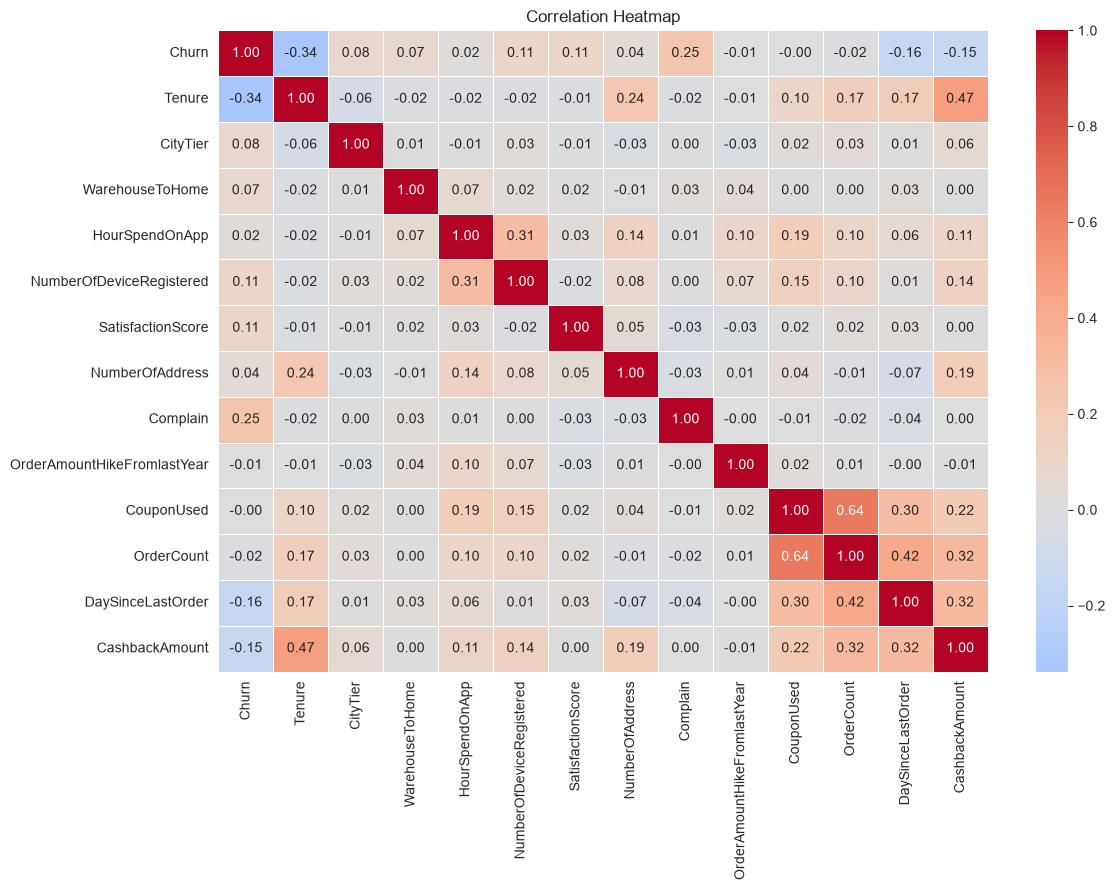

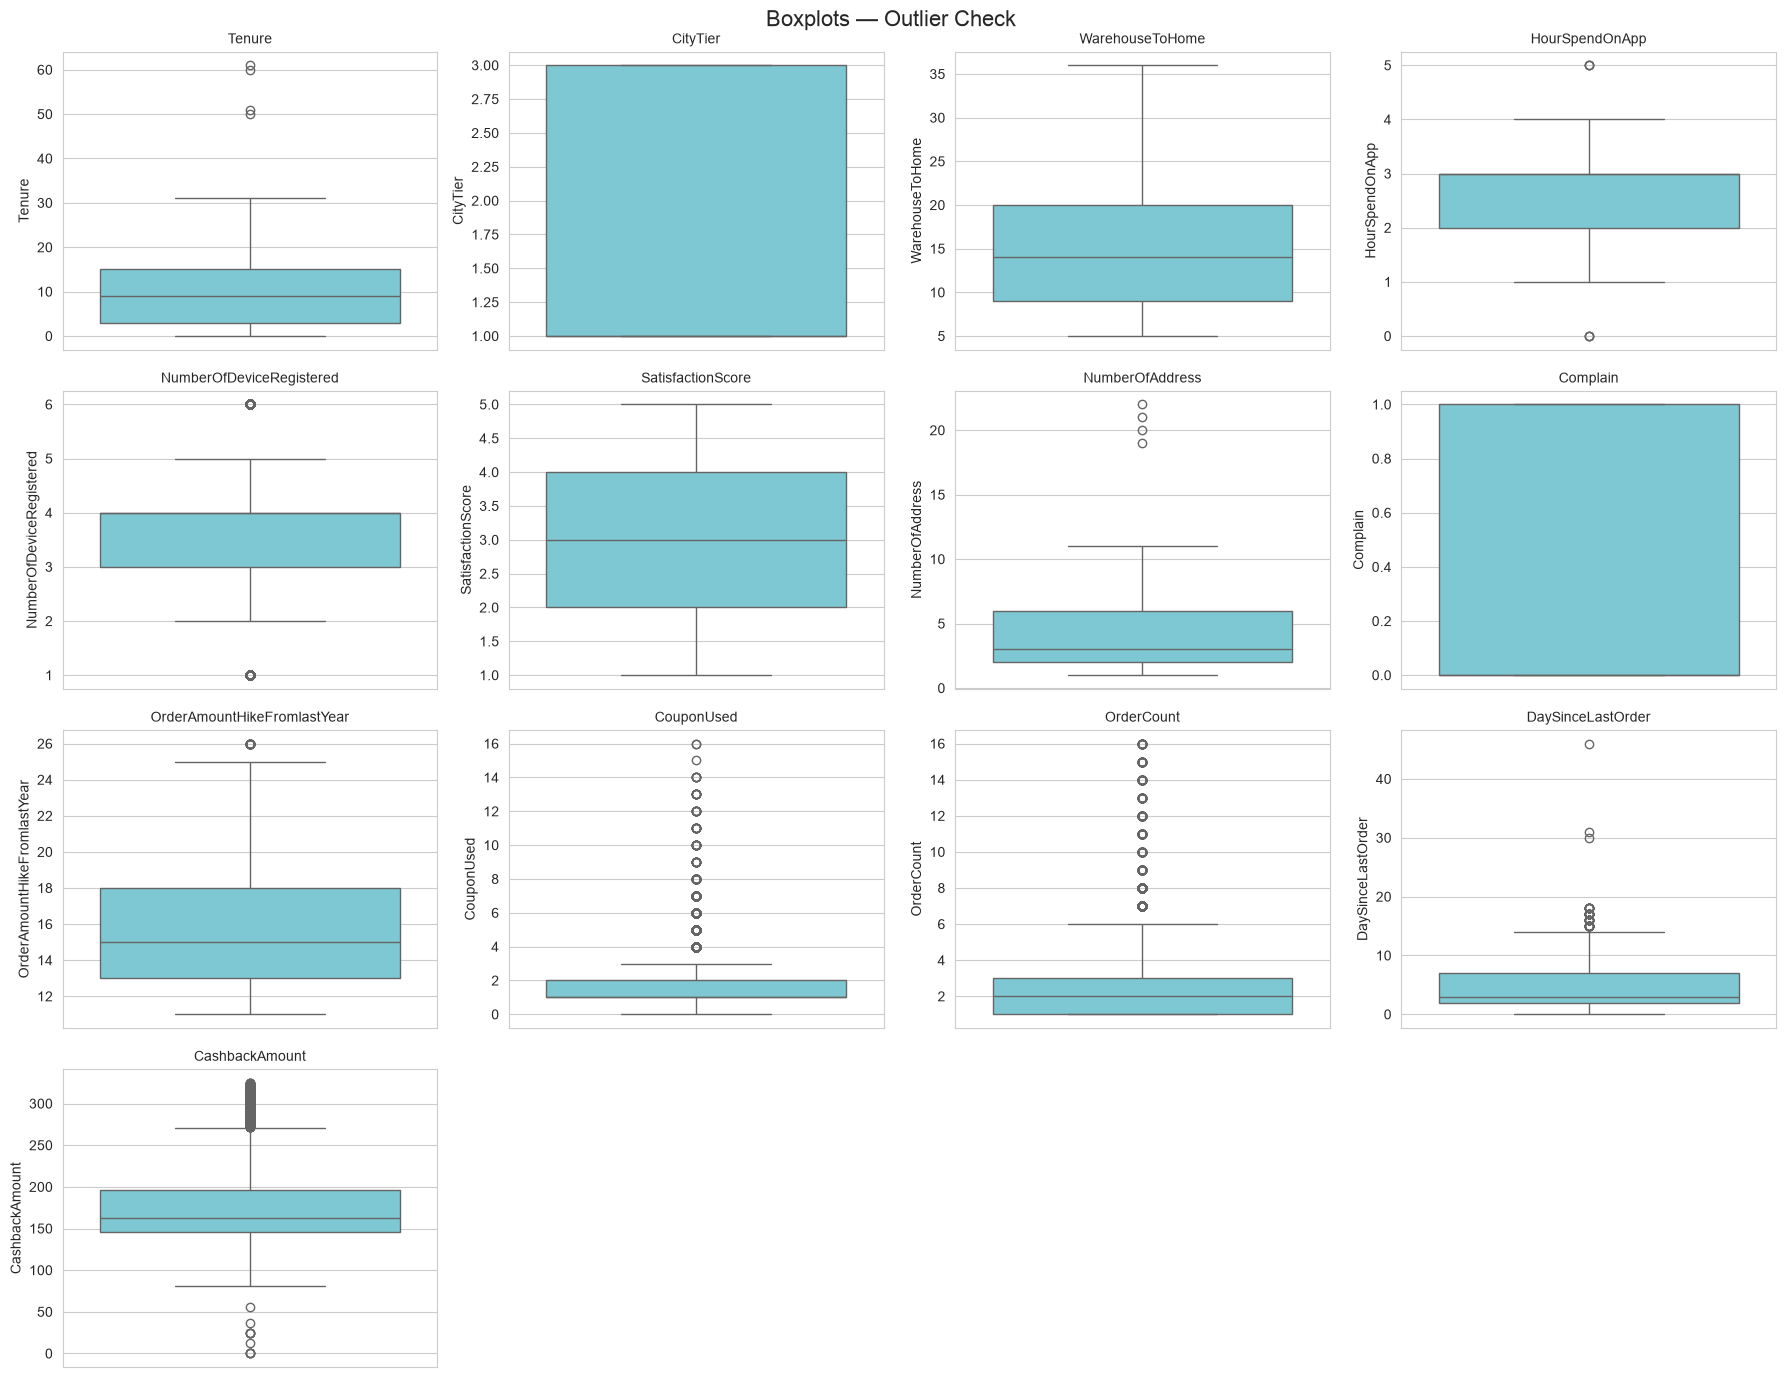


Outlier Summary (IQR method):
                     Feature  Lower Bound  Upper Bound  Outlier Count  Outlier %
                 OrderCount         -2.0          6.0            703      12.49
                 CouponUsed         -0.5          3.5            629      11.17
             CashbackAmount         71.0        271.0            447       7.94
   NumberOfDeviceRegistered          1.5          5.5            397       7.05
          DaySinceLastOrder         -5.5         14.5             62       1.10
OrderAmountHikeFromlastYear          5.5         25.5             33       0.59
             HourSpendOnApp          0.5          4.5              6       0.11
                     Tenure        -15.0         33.0              4       0.07
            NumberOfAddress         -4.0         12.0              4       0.07
                   CityTier         -2.0          6.0              0       0.00
            WarehouseToHome         -7.5         36.5              0       0.00
        

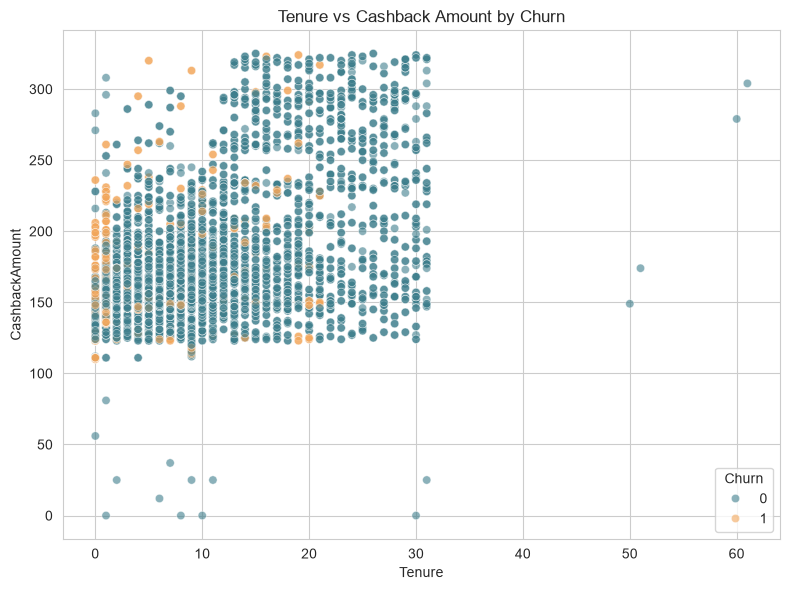

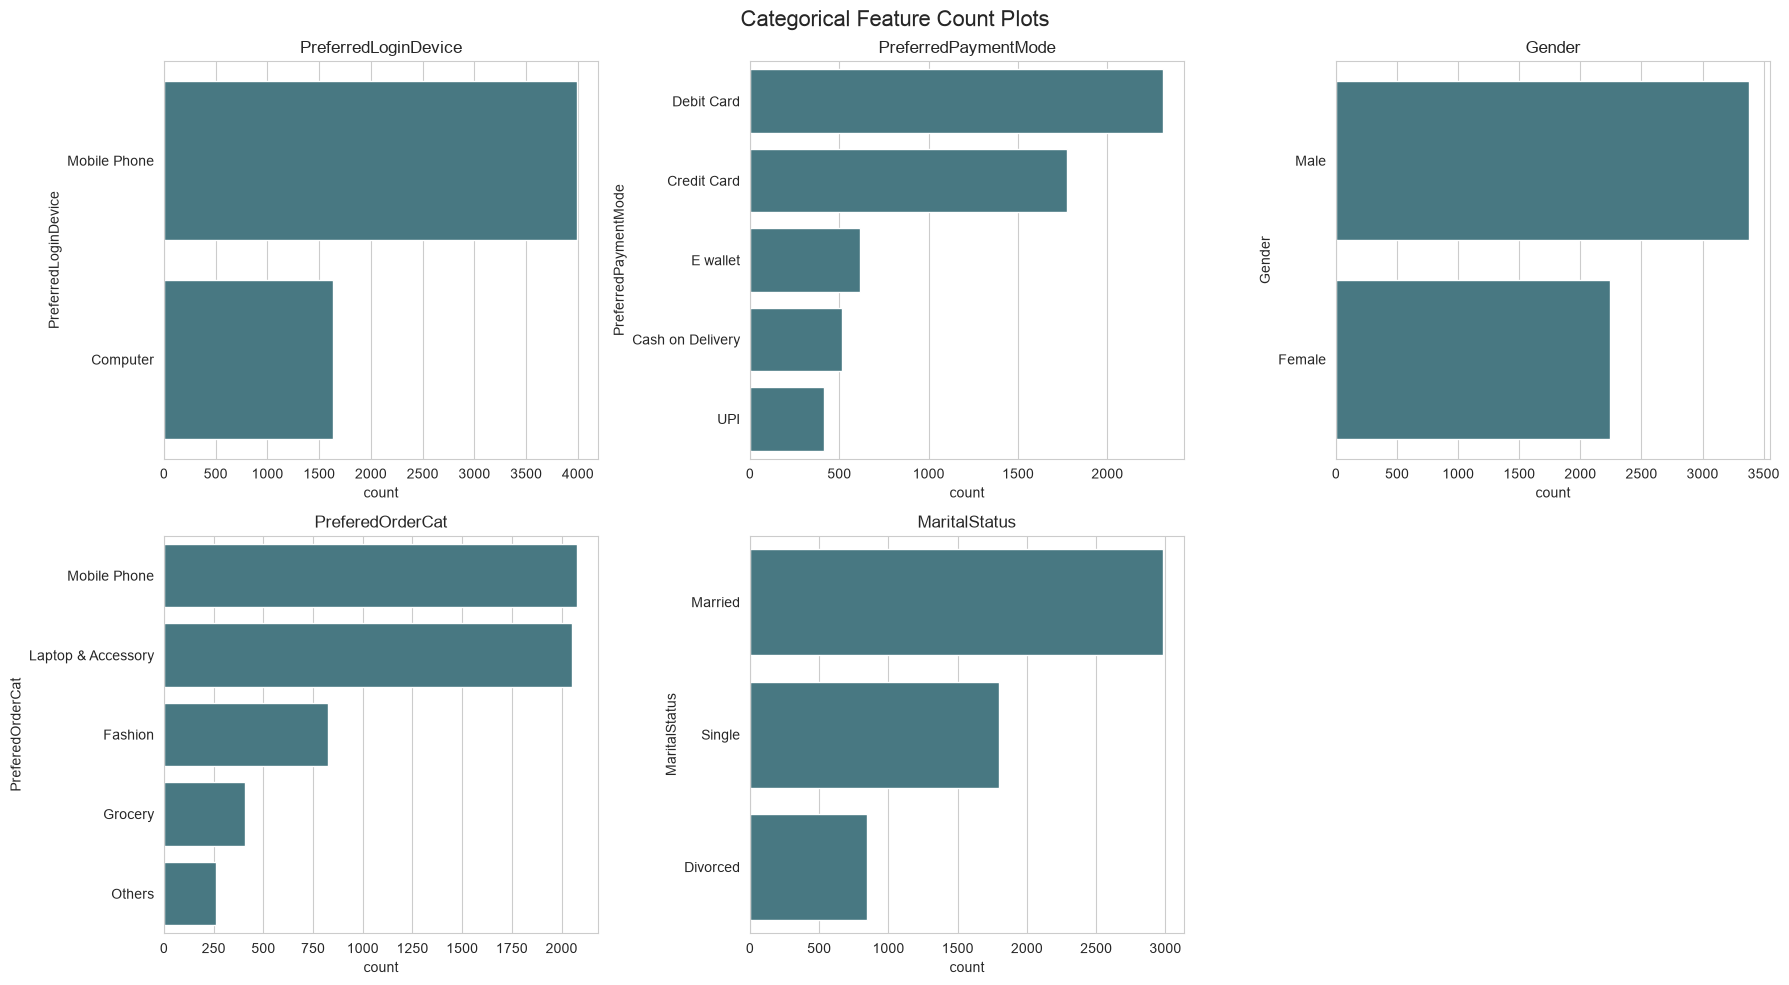


EDA complete.


In [10]:
# =========================================================
# EXPLORATORY DATA ANALYSIS — E-Commerce Churn Dataset
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/Customer-Retention-intelligence-Platform/DataSet/cleaned/E_Comm_Cleaned_Final.csv')


# ---------------------------------------------------------
# 1. DATASET HEALTH CHECK
# ---------------------------------------------------------
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal duplicate rows:", df.duplicated().sum())

# ---------------------------------------------------------
# 2. NUMERIC FEATURES — SHAPE + SKEWNESS
# ---------------------------------------------------------
num_cols = df.select_dtypes(include='number').columns.drop(['CustomerID', 'Churn'])

print("\nNumeric summary:\n", df[num_cols].describe().T)
print("\nSkewness:\n", df[num_cols].skew().sort_values(ascending=False))

# ---------------------------------------------------------
# 3. TARGET VARIABLE DISTRIBUTION (Churn)
# ---------------------------------------------------------
print("\nChurn counts:\n", df['Churn'].value_counts())
print("\nChurn %:\n", (df['Churn'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', hue='Churn', data=df, palette=['#3E7E8C', '#F2A65A'], legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. NUMERICAL DISTRIBUTION (Histograms)
# ---------------------------------------------------------
df[num_cols].hist(figsize=(16, 12), bins=25, color='#3E7E8C', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. CORRELATION HEATMAP
# ---------------------------------------------------------
corr_cols = df.select_dtypes(include='number').columns.drop(['CustomerID'])
corr = df[corr_cols].corr()

print("\nCorrelation with Churn:\n", corr['Churn'].sort_values(ascending=False))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. BOXPLOTS + OUTLIER DETECTION (IQR method)
# ---------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#6FD3E0')
    axes[i].set_title(col, fontsize=10)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots — Outlier Check', fontsize=16)
plt.tight_layout()
plt.show()

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print("\nOutlier Summary (IQR method):\n", outlier_df.to_string(index=False))

# ---------------------------------------------------------
# 7. SCATTER PLOT (Tenure vs CashbackAmount, colored by Churn)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure', y='CashbackAmount', hue='Churn', data=df,
                 palette=['#3E7E8C', '#F2A65A'], alpha=0.6)
plt.title('Tenure vs Cashback Amount by Churn')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. COUNT PLOTS FOR CATEGORICAL FEATURES
# ---------------------------------------------------------
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, ax=axes[i],
                  order=df[col].value_counts().index, color='#3E7E8C')
    axes[i].set_title(col)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Categorical Feature Count Plots', fontsize=16)
plt.tight_layout()
plt.show()

print("\nEDA complete.")